# Лабораторная работа № 2
## Методы машинного обучения и обработки естественного языка для анализа юридических текстов

In [2]:
# Установка необходимых библиотек
# Выполните эту ячейку перед началом работы

# !pip install scikit-learn numpy pandas matplotlib seaborn
# !pip install pymorphy2 pymorphy2-dicts-ru nltk
# !pip install gensim wordcloud

import warnings
warnings.filterwarnings('ignore')

import re
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# scikit-learn
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, IsolationForest
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE

# Морфологический анализ
import pymorphy2
import nltk

# nltk.download('punkt', quiet=True)
# nltk.download('stopwords', quiet=True)

# Фиксация случайности для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Все библиотеки успешно импортированы.")
print(f"Версия scikit-learn: {__import__('sklearn').__version__}")
print(f"Версия NumPy: {np.__version__}")
print(f"Версия pandas: {pd.__version__}")

Все библиотеки успешно импортированы.
Версия scikit-learn: 1.6.1
Версия NumPy: 1.26.4
Версия pandas: 2.2.3


## 3. Генератор учебного корпуса судебных документов

In [3]:
# ============================================================
# Генератор учебного корпуса судебных документов
# ============================================================

import pymorphy3 as pymorphy2

morph = pymorphy2.MorphAnalyzer()

# Русские стоп-слова (расширенный список для юридических текстов)
LEGAL_STOPWORDS = set([
    'в', 'на', 'и', 'с', 'по', 'к', 'за', 'у', 'о', 'из', 'не', 'он', 'она',
    'они', 'что', 'как', 'это', 'при', 'от', 'до', 'а', 'но', 'или', 'же',
    'ли', 'бы', 'для', 'об', 'со', 'также', 'то', 'во', 'да', 'нет', 'быть',
    'суд', 'дело', 'рф', 'российский', 'федерация', 'именем', 'заседание',
    'рассмотрев', 'изучив', 'исследовав', 'выслушав', 'установил', 'постановил',
    'решил', 'определил', 'который', 'которая', 'которые', 'этот', 'этот',
    'свой', 'такой', 'весь', 'один', 'так', 'же', 'вот', 'уже', 'даже',
    'ещё', 'тогда', 'тоже', 'сам', 'тут', 'там', 'где', 'когда', 'если',
])

# ──────────────────────────────────────────────────────────────
# Шаблоны документов по категориям
# ──────────────────────────────────────────────────────────────

CORPUS_TEMPLATES = {

    # ── Гражданские споры ──
    'семейное': [
        "расторжение брак истец ответчик совместно нажитое имущество раздел",
        "взыскание алименты несовершеннолетний ребёнок содержание уплата",
        "установление отцовство генетическая экспертиза биологическое происхождение",
        "лишение родительских прав ненадлежащее исполнение обязанность воспитание",
        "определение место жительство ребёнок развод родитель опека",
        "усыновление удочерение органы опека согласие биологический родитель",
        "взыскание алименты нетрудоспособный родитель содержание обязанность",
        "раздел совместное имущество супруг квартира автомобиль вклад",
        "признание брака недействительным обман принуждение фиктивный",
        "изменение размера алиментов материальное положение обстоятельства",
    ],
    'трудовое': [
        "незаконное увольнение восстановление работа трудовой договор нарушение",
        "взыскание задолженность заработная плата невыплата работодатель",
        "дискриминация трудовые отношения отказ приём работу незаконный",
        "производственная травма возмещение вред здоровью несчастный случай",
        "компенсация вынужденный прогул незаконное отстранение сотрудник",
        "расторжение трудовой договор соглашение сторон нарушение процедура",
        "взыскание выходное пособие сокращение штат ликвидация организация",
        "восстановление нарушенных прав декретный отпуск беременная женщина",
        "задержка выплата расчёт увольнение трудовая книжка нарушение",
        "незаконный перевод должность ухудшение условий труда согласие",
    ],
    'имущественное': [
        "взыскание долг договор займа невозврат денежные средства",
        "признание право собственность недвижимость регистрация оформление",
        "истребование имущество незаконное владение виндикационный иск",
        "возмещение ущерб повреждение имущество заливание квартира сосед",
        "исполнение обязательство договор поставка товар оплата претензия",
        "признание сделка недействительная мошенничество обман принуждение",
        "взыскание неустойка нарушение срок исполнение договорных обязательств",
        "раздел наследство завещание наследник очередь право собственность",
        "устранение препятствий пользование общедолевое имущество сосед",
        "регрессное требование страховая компания виновник ДТП возмещение",
    ],
    'жилищное': [
        "выселение незаконное проживание отсутствие регистрация нарушение права",
        "признание право пользование жилое помещение договор социальный найм",
        "перевод жилое нежилое помещение согласование реконструкция самовольная",
        "взыскание задолженность коммунальные услуги долг управляющая компания",
        "признание жилье аварийным расселение ветхий жилой фонд снос",
        "обязать обеспечить жилое помещение сирота льготная очередь субсидия",
        "сохранение перепланировки переустройства жилье разрешение узаконивание",
        "взыскание убытки ненадлежащее содержание общее имущество многоквартирный дом",
        "признание нанимателя утратившим право пользование длительное отсутствие",
        "приватизация жилое помещение государственный муниципальный фонд оформление",
    ],

    # ── Уголовные дела ──
    'против_личности': [
        "осуждён причинение тяжкий вред здоровью умышленное нападение оружие",
        "приговор угроза убийством словесные угрозы опасение реальность",
        "хулиганство грубое нарушение общественный порядок применение насилие",
        "побои лёгкий вред здоровью систематическое нанесение ударов",
        "клевета распространение заведомо ложные сведения репутация потерпевший",
        "оскорбление унижение чести достоинство публичное высказывание",
        "доведение самоубийство психологическое давление угрозы зависимость",
        "незаконное лишение свободы удержание помещение ограничение передвижение",
        "похищение человека удержание выкуп организованная группа преступление",
        "истязание систематическое нанесение побоев особая жестокость мучение",
    ],
    'против_собственности': [
        "кража тайное похищение имущество незаконное проникновение жилище",
        "мошенничество обман злоупотребление доверие хищение денежные средства",
        "грабёж открытое хищение имущество применение насилие опасность здоровью",
        "разбой нападение завладение чужое имущество угроза применение насилие",
        "вымогательство требование передать имущество угроза насилие шантаж",
        "присвоение растрата вверенное имущество полномочия злоупотребление",
        "угон транспортное средство неправомерное завладение без цели хищения",
        "уничтожение повреждение чужое имущество поджог умышленное действие",
        "мошенничество сфера кредитование заведомо ложные сведения банк",
        "хищение компьютерная информация электронный платёж несанкционированный",
    ],
    'экономические': [
        "уклонение уплата налог крупный размер организация скрытие доходов",
        "незаконная предпринимательская деятельность лицензия нарушение порядок",
        "контрабанда незаконное перемещение товар граница таможня сокрытие",
        "легализация доходы преступный путь отмывание финансовые операции",
        "фальсификация финансовый документ бухгалтерская отчётность мошенничество",
        "незаконный оборот валюта иностранный счёт нарушение валютное законодательство",
        "злоупотребление полномочие должностное лицо корыстный мотив ущерб",
        "взятка коммерческий подкуп должностное лицо получение передача незаконное",
        "банкротство преднамеренное сокрытие имущество кредитор уголовная ответственность",
        "мошенничество страхование ложные сведения страховой случай выплата",
    ],
    'наркотики': [
        "незаконное хранение наркотик значительный размер без цель сбыт",
        "сбыт наркотический средство организованная группа крупный размер",
        "изготовление наркотик психотропное вещество синтетический аналог",
        "организация наркопритон помещение систематическое употребление",
        "склонение употреблению наркотик несовершеннолетний злоупотребление",
        "контрабанда наркотик ввоз территория государственная граница сокрытие",
        "хранение прекурсор производство наркотическое вещество незаконный",
        "финансирование наркоторговля преступная организация доходы деятельность",
        "незаконный оборот наркотик особо крупный размер организованная группа",
        "потребление наркотик без назначение врача административная ответственность",
    ],

    # ── Административные ──
    'пдд': [
        "превышение скорость нарушение правила дорожного движения штраф",
        "проезд запрещающий сигнал светофора нарушение правило штраф предупреждение",
        "управление транспортное средство состояние опьянение лишение права",
        "оставление место ДТП нарушение обязанность водитель административный",
        "непристёгнутый ремень безопасность нарушение требование безопасность движение",
        "выезд встречная полоса нарушение разметка дорожный знак обгон",
        "отказ медицинское освидетельствование алкогольное опьянение лишение",
        "нарушение правило стоянки парковки городская территория эвакуация",
        "управление без водительского удостоверения право управление лишение",
        "неуплата штраф нарушение ПДД исполнительное производство задолженность",
    ],
    'санитарные': [
        "нарушение санитарное эпидемиологическое требование организация производство",
        "несоблюдение санитарный норм правил предприятие общественное питание",
        "нарушение требование хранение пищевой продукт санитарные условия",
        "проведение дезинфекция дезинсекция медицинская организация нарушение",
        "нарушение санитарное норма образовательная организация детское учреждение",
        "несоответствие питьевая вода гигиеническим нормативам водопровод система",
        "нарушение правил обращения медицинские отходы утилизация больница",
        "отсутствие санитарная книжка персонал нарушение требование допуск",
        "нарушение карантинный мероприятия инфекционные заболевания изоляция",
        "ненадлежащее качество пищевой продукт нарушение маркировка состав",
    ],
    'налоговые_адм': [
        "непредставление налоговая декларация истечение срок нарушение обязанность",
        "нарушение срок уплата налог авансовый платёж пени штраф",
        "грубое нарушение правила учёт доходы расходы объект налогообложения",
        "непредоставление сведения налоговый орган запрос контрольная проверка",
        "нарушение порядок применение контрольно-кассовая техника розничная торговля",
        "уклонение регистрация индивидуальный предприниматель обязательная постановка",
        "нарушение ведение кассовые операции превышение лимит остаток наличность",
        "воспрепятствование выездная налоговая проверка доступ помещение документы",
        "нарушение срок постановка учёт налоговый орган регистрация организация",
        "непредоставление документы информация налоговая проверка штраф взыскание",
    ],
    'пожарные': [
        "нарушение требование пожарная безопасность организация объект эксплуатация",
        "отсутствие автоматическая пожарная сигнализация нарушение нормативные требования",
        "ненадлежащее состояние эвакуационный путь выход захламлённость блокировка",
        "нарушение правил хранение горючие жидкости взрывоопасные материалы",
        "отсутствие первичные средства пожаротушение огнетушитель противопожарный щит",
        "нарушение требование электроустановка проводка пожарная опасность",
        "несоответствие здание строительные нормы противопожарные требования",
        "нарушение порядок проведение пожарный инструктаж журнал обучение персонал",
        "эксплуатация неисправные средства противопожарной защиты детектор дым",
        "нарушение правила устройство эксплуатация отопительная система безопасность",
    ],

    # ── Арбитражные ──
    'корпоративные': [
        "оспаривание решение общее собрание акционер нарушение порядок созыв",
        "взыскание убытки директор злоупотребление полномочие ущерб компания",
        "признание недействительность крупная сделка корпоративное одобрение",
        "исключение участник ООО существенный нарушение обязанность ущерб",
        "обязать созыв внеочередного собрания участников требование акционер",
        "оспаривание сделка заинтересованность директор аффилированное лицо",
        "взыскание дивиденд решение распределить прибыль невыплата акционер",
        "признание ничтожности решение совет директоров отсутствие кворум",
        "понуждение регистрация изменение устав запись ЕГРЮЛ отказ регистратор",
        "защита преимущественное право покупка доли нарушение участник ООО",
    ],
    'банкротство': [
        "признание должник несостоятельный банкротство открытие конкурсное производство",
        "включение требования кредитора реестр требований банкротство задолженность",
        "оспаривание сделка должника преимущественное удовлетворение кредитор вред",
        "привлечение контролирующее лицо субсидиарная ответственность долг кредитор",
        "введение наблюдение финансовый анализ платёжеспособность должник",
        "утверждение план финансового оздоровления погашение задолженность кредитор",
        "жалоба действие конкурсный управляющий нарушение закон банкротство",
        "завершение конкурсное производство ликвидация должник имущество реализация",
        "погашение задолженность реестровый требования текущий платёж очерёдность",
        "мировое соглашение кредитор должник утверждение арбитражным судом",
    ],
    'налоговые_арб': [
        "признание решения налогового органа недействительным доначисление налог",
        "возврат излишне уплаченный налог отказ налоговый орган заявление",
        "оспаривание решения выездная налоговая проверка нарушение процедура",
        "взыскание налоговый орган неправомерный отказ возмещение НДС",
        "признание незаконным решение привлечение ответственности налоговый правонарушение",
        "зачёт переплата налог уточнённая декларация изменение налоговое обязательство",
        "оспаривание действие должностного лица налоговый орган нарушение права",
        "заявление обеспечительные меры налоговый спор приостановление взыскание",
        "взыскание процентов нарушение срок возврат излишне уплаченный налог",
        "признание безнадёжной задолженность списание налоговый долг истечение срок",
    ],
    'контрактные': [
        "взыскание неустойка нарушение срок исполнение договор поставка подряд",
        "расторжение договора существенное нарушение обязательство односторонний",
        "взыскание убытки ненадлежащее исполнение договор подряд некачественный",
        "понуждение исполнению обязательство в натуре заключение договор уклонение",
        "взыскание долга договор поставка оказание услуги оплата задолженность",
        "признание договора незаключённым несогласование существенное условие",
        "изменение договора существенное изменение обстоятельства форс-мажор",
        "взыскание аванс неосновательное обогащение неисполнение обязательство",
        "обеспечение исполнения договора банковская гарантия залог поручительство",
        "убытки срыв поставки срок просрочка пени штраф контрактное обязательство",
    ],

    # ── Смешанный ──
    'гражданское_общее': [
        "взыскание задолженность договор гражданско-правовые отношения истец ответчик",
        "иск удовлетворить частично нарушение гражданское право требование",
        "признание договора недействительным нарушение законодательства ГК РФ",
        "возмещение убытков нарушение договорных обязательств гражданский ущерб",
        "обязать ответчика исполнить обязательство гражданское судопроизводство",
    ],
    'уголовное_общее': [
        "приговор виновен совершение преступления наказание уголовный кодекс",
        "оправдательный приговор недоказанность вина отсутствие состав преступление",
        "условное осуждение испытательный срок пробационный контроль надзор",
        "назначение наказание учёт обстоятельства смягчение отягчение вина",
        "признание виновным лишение свободы реальный срок отбывание наказание",
    ],
    'административное_общее': [
        "административный штраф нарушение нормативные требования предписание",
        "прекращение производство административное правонарушение истечение срок",
        "назначение административный арест правонарушение повторность злостный",
        "предупреждение административное нарушение впервые незначительность",
        "конфискация предмет административного правонарушения изъятие",
    ],
    'арбитражное_общее': [
        "удовлетворение требований арбитражный суд взыскание задолженность бизнес",
        "отказ иска арбитражное производство процессуальный нарушение срок исковой",
        "мировое соглашение стороны урегулирование коммерческий спор выгода",
        "обеспечительные меры арест счёт запрет сделка сохранение имущество",
        "апелляция обжалование решение первая инстанция арбитражного суда",
    ],
}

# Категории по типу корпуса (для таблицы вариантов)
CORPUS_CONFIG = {
    'A': {  # Гражданские
        'categories': ['семейное', 'трудовое', 'имущественное', 'жилищное'],
        'label': 'Гражданские споры',
        'description': 'семейные, трудовые, имущественные и жилищные дела'
    },
    'B': {  # Уголовные
        'categories': ['против_личности', 'против_собственности',
                       'экономические', 'наркотики'],
        'label': 'Уголовные дела',
        'description': 'преступления против личности, собственности, экономические и наркодела'
    },
    'C': {  # Административные
        'categories': ['пдд', 'санитарные', 'налоговые_адм', 'пожарные'],
        'label': 'Административные правонарушения',
        'description': 'нарушения ПДД, санитарные, налоговые и пожарные правонарушения'
    },
    'D': {  # Арбитражные
        'categories': ['корпоративные', 'банкротство',
                       'налоговые_арб', 'контрактные'],
        'label': 'Арбитражные споры',
        'description': 'корпоративные, банкротные, налоговые и контрактные споры'
    },
    'E': {  # Смешанный
        'categories': ['гражданское_общее', 'уголовное_общее',
                       'административное_общее', 'арбитражное_общее'],
        'label': 'Смешанный корпус',
        'description': 'гражданские, уголовные, административные и арбитражные дела'
    },
}


def generate_corpus(corpus_type: str = 'A',
                    n_per_class: int = 80,
                    seed: int = 42) -> pd.DataFrame:
    """
    Генерирует синтетический корпус судебных документов.

    Args:
        corpus_type: Тип корпуса — 'A', 'B', 'C', 'D' или 'E'.
        n_per_class: Количество документов каждой категории.
        seed: Инициализатор генератора случайных чисел.

    Returns:
        DataFrame с колонками 'text' (текст) и 'label' (категория).
    """
    rng = random.Random(seed)
    cfg = CORPUS_CONFIG[corpus_type]
    records = []

    # Дополнительные «шумовые» фразы — имитация судебного стиля
    noise_phrases = [
        "рассмотрев материалы дела суд установил следующее",
        "изучив представленные доказательства суд пришёл выводу",
        "выслушав стороны исследовав материалы дела",
        "проверив доводы жалобы изучив обстоятельства",
        "оценив совокупность доказательств суд считает",
        "принимая во внимание фактические обстоятельства дела",
        "руководствуясь нормами действующего законодательства",
        "в соответствии требованиями процессуального кодекса",
        "суд не находит оснований удовлетворения требований",
        "доводы ответчика подтверждены представленными материалами",
    ]

    for label in cfg['categories']:
        templates = CORPUS_TEMPLATES[label]
        for i in range(n_per_class):
            # Основной шаблон + шумовая фраза + вариация длины
            main = rng.choice(templates)
            extra = rng.choice(noise_phrases)
            # Небольшое лексическое варьирование
            rep = rng.choice([
                "истец просит", "суд полагает", "ответчик возражает",
                "прокурор поддерживает", "защитник ходатайствует",
                "эксперт указывает", "свидетель подтверждает",
            ])
            text = f"{main} {extra} {rep}"
            records.append({'text': text, 'label': label})

    df = pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


# ── Демонстрация: генерация корпуса типа A ──
demo_df = generate_corpus('A', n_per_class=5)
print("Пример сгенерированного корпуса (тип A — гражданские споры):")
print(demo_df.to_string(max_colwidth=80))

Пример сгенерированного корпуса (тип A — гражданские споры):
                                                                               text          label
0   взыскание алименты несовершеннолетний ребёнок содержание уплата рассмотрев м...       семейное
1   признание право пользование жилое помещение договор социальный найм руководс...       жилищное
2   обязать обеспечить жилое помещение сирота льготная очередь субсидия доводы о...       жилищное
3   определение место жительство ребёнок развод родитель опека проверив доводы ж...       семейное
4   задержка выплата расчёт увольнение трудовая книжка нарушение руководствуясь ...       трудовое
5   взыскание задолженность заработная плата невыплата работодатель проверив дов...       трудовое
6   взыскание неустойка нарушение срок исполнение договорных обязательств приним...  имущественное
7   признание брака недействительным обман принуждение фиктивный изучив представ...       семейное
8   признание нанимателя утратившим право пользо

## 4. Вспомогательные функции предобработки текста

In [4]:
# ============================================================
# Функции предобработки текстов
# ============================================================

_morph = pymorphy2.MorphAnalyzer()


def clean_text(text: str) -> str:
    """Удаляет спецсимволы, нормализует пробелы, приводит к нижнему регистру."""
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML-теги
    text = re.sub(r'[^\w\s]', ' ', text)          # пунктуация
    text = re.sub(r'\d+', ' ', text)               # цифры
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()


def lemmatize(text: str,
              remove_stopwords: bool = True,
              min_len: int = 3) -> str:
    """
    Лемматизирует текст через pymorphy2.

    Args:
        text: Предварительно очищенный текст.
        remove_stopwords: Удалять ли стоп-слова.
        min_len: Минимальная длина токена.

    Returns:
        Строка лемм, разделённых пробелами.
    """
    lemmas = []
    for token in text.split():
        if len(token) < min_len:
            continue
        parsed = _morph.parse(token)
        if not parsed:
            continue
        lemma = parsed[0].normal_form
        if remove_stopwords and lemma in LEGAL_STOPWORDS:
            continue
        lemmas.append(lemma)
    return ' '.join(lemmas)


def preprocess(text: str) -> str:
    """Полный конвейер: очистка → лемматизация."""
    return lemmatize(clean_text(text))


def preprocess_corpus(df: pd.DataFrame,
                      text_col: str = 'text') -> pd.Series:
    """Применяет предобработку ко всему корпусу."""
    return df[text_col].apply(preprocess)


# ── Тест предобработки ──
sample = """Рассмотрев материалы дела №2-1234/2023 суд установил:
истец Иванов И.И. обратился с иском о взыскании задолженности
по договору займа в размере 150 000 рублей."""

print("Исходный текст:")
print(sample)
print("\nПосле очистки:")
print(clean_text(sample))
print("\nПосле лемматизации:")
print(lemmatize(clean_text(sample)))


Исходный текст:
Рассмотрев материалы дела №2-1234/2023 суд установил:
истец Иванов И.И. обратился с иском о взыскании задолженности
по договору займа в размере 150 000 рублей.

После очистки:
рассмотрев материалы дела суд установил истец иванов и и обратился с иском о взыскании задолженности по договору займа в размере рублей

После лемматизации:
рассмотреть материал установить истец иванов обратиться иск взыскание задолженность договор заём размер рубль


## 6. Задания лабораторной работы

In [5]:
CORPUS_TYPE = 'D'   # <-- замените согласно своему варианту 19

# ── 1.1 Генерация и предобработка корпуса ──────────────────
df = generate_corpus(CORPUS_TYPE, n_per_class=80, seed=RANDOM_STATE)
df['processed'] = preprocess_corpus(df)

print(f"=== Корпус: {CORPUS_CONFIG[CORPUS_TYPE]['label']} ===")
print(f"Всего документов:  {len(df)}")
print(f"Число классов:     {df['label'].nunique()}")
print(f"Классы: {df['label'].unique().tolist()}")
print(f"\nРаспределение по классам:")
print(df['label'].value_counts().to_string())

=== Корпус: Арбитражные споры ===
Всего документов:  320
Число классов:     4
Классы: ['налоговые_арб', 'корпоративные', 'банкротство', 'контрактные']

Распределение по классам:
label
налоговые_арб    80
корпоративные    80
банкротство      80
контрактные      80


In [6]:
# ── 1.2 Анализ длин документов ─────────────────────────────
df['n_tokens'] = df['processed'].apply(lambda x: len(x.split()))
print(f"\n=== Статистика длин документов (в леммах) ===")
print(df['n_tokens'].describe().round(2).to_string())


=== Статистика длин документов (в леммах) ===
count    320.00
mean      13.36
std        0.93
min       11.00
25%       13.00
50%       13.00
75%       14.00
max       16.00


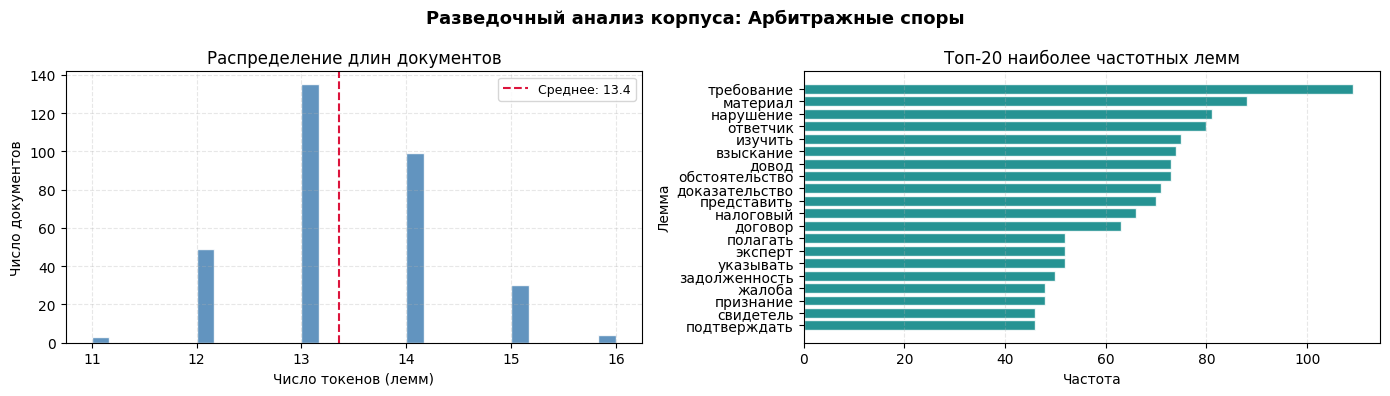

In [7]:
# ── 1.3 Визуализация ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма длин
axes[0].hist(df['n_tokens'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set(title='Распределение длин документов',
            xlabel='Число токенов (лемм)', ylabel='Число документов')
axes[0].axvline(df['n_tokens'].mean(), color='crimson', linestyle='--',
                label=f"Среднее: {df['n_tokens'].mean():.1f}")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, linestyle='--')

# Топ-20 слов
all_tokens = ' '.join(df['processed'].tolist()).split()
top_words = Counter(all_tokens).most_common(20)
words_, freqs_ = zip(*top_words)
axes[1].barh(list(reversed(words_)), list(reversed(freqs_)),
             color='teal', alpha=0.85, edgecolor='white')
axes[1].set(title='Топ-20 наиболее частотных лемм',
            xlabel='Частота', ylabel='Лемма')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(f'Разведочный анализ корпуса: '
             f'{CORPUS_CONFIG[CORPUS_TYPE]["label"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_eda.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ── 1.4 Разбивка на обучающую и тестовую выборки ──────────
X_raw = df['processed'].tolist()
y = df['label'].tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\n=== Разбивка выборки ===")
print(f"Обучающая: {len(X_train_raw)} документов")
print(f"Тестовая:  {len(X_test_raw)} документов")


=== Разбивка выборки ===
Обучающая: 256 документов
Тестовая:  64 документов


### Задание 2. Извлечение признаков (метод определяется вариантом)

In [9]:
# ── Замените эту строку на нужный векторизатор ──────────────
vectorizer = CountVectorizer(max_features=2000, min_df=2)

# ── Обучение и преобразование ───────────────────────────────
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f"=== Признаковое пространство ===")
print(f"Форма X_train: {X_train.shape}  (документы × признаки)")
print(f"Форма X_test:  {X_test.shape}")

# Разреженность
nonzero_ratio = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f"Доля ненулевых элементов: {nonzero_ratio:.6f} ({nonzero_ratio*100:.4f}%)")
print(f"Разреженность:           {1 - nonzero_ratio:.6f}")

=== Признаковое пространство ===
Форма X_train: (256, 204)  (документы × признаки)
Форма X_test:  (64, 204)
Доля ненулевых элементов: 0.065104 (6.5104%)
Разреженность:           0.934896


In [10]:
# Топ-10 признаков по суммарному весу
feature_names = vectorizer.get_feature_names_out()
col_sums = np.asarray(X_train.sum(axis=0)).flatten()
top10_idx = np.argsort(col_sums)[::-1][:10]
print(f"\nТоп-10 наиболее весомых признаков:")
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:2d}. '{feature_names[idx]}'  вес={col_sums[idx]:.4f}")


Топ-10 наиболее весомых признаков:
   1. 'требование'  вес=91.0000
   2. 'материал'  вес=67.0000
   3. 'ответчик'  вес=64.0000
   4. 'изучить'  вес=61.0000
   5. 'нарушение'  вес=60.0000
   6. 'довод'  вес=60.0000
   7. 'доказательство'  вес=60.0000
   8. 'обстоятельство'  вес=59.0000
   9. 'взыскание'  вес=58.0000
  10. 'представить'  вес=55.0000


### Задание 3. Обучение и оценка классификатора (по варианту)

In [11]:
# ── Основной классификатор: LogisticRegression ─────────────
main_clf = LogisticRegression(C=1.0, max_iter=1000,
                               random_state=RANDOM_STATE,
                               multi_class='multinomial')

# ── Кросс-валидация (5 фолдов) ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(main_clf, X_train, y_train,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"=== Кросс-валидация (5-fold, F₁-weighted) ===")
print(f"Оценки по фолдам: {[round(s, 4) for s in cv_scores]}")
print(f"Среднее:   {cv_scores.mean():.4f}")
print(f"Std:       {cv_scores.std():.4f}")

=== Кросс-валидация (5-fold, F₁-weighted) ===
Оценки по фолдам: [1.0, 1.0, 1.0, 1.0, 1.0]
Среднее:   1.0000
Std:       0.0000


In [12]:
# ── Обучение на полной обучающей выборке ───────────────────
main_clf.fit(X_train, y_train)
y_pred_main = main_clf.predict(X_test)

acc_main  = accuracy_score(y_test, y_pred_main)
f1m_main  = f1_score(y_test, y_pred_main, average='macro')
f1w_main  = f1_score(y_test, y_pred_main, average='weighted')

print(f"\n=== Тестовая выборка: основной классификатор ===")
print(f"Accuracy:    {acc_main:.4f}")
print(f"F₁-macro:    {f1m_main:.4f}")
print(f"F₁-weighted: {f1w_main:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred_main, digits=4))


=== Тестовая выборка: основной классификатор ===
Accuracy:    1.0000
F₁-macro:    1.0000
F₁-weighted: 1.0000

Подробный отчёт:
               precision    recall  f1-score   support

  банкротство     1.0000    1.0000    1.0000        16
  контрактные     1.0000    1.0000    1.0000        16
корпоративные     1.0000    1.0000    1.0000        16
налоговые_арб     1.0000    1.0000    1.0000        16

     accuracy                         1.0000        64
    macro avg     1.0000    1.0000    1.0000        64
 weighted avg     1.0000    1.0000    1.0000        64



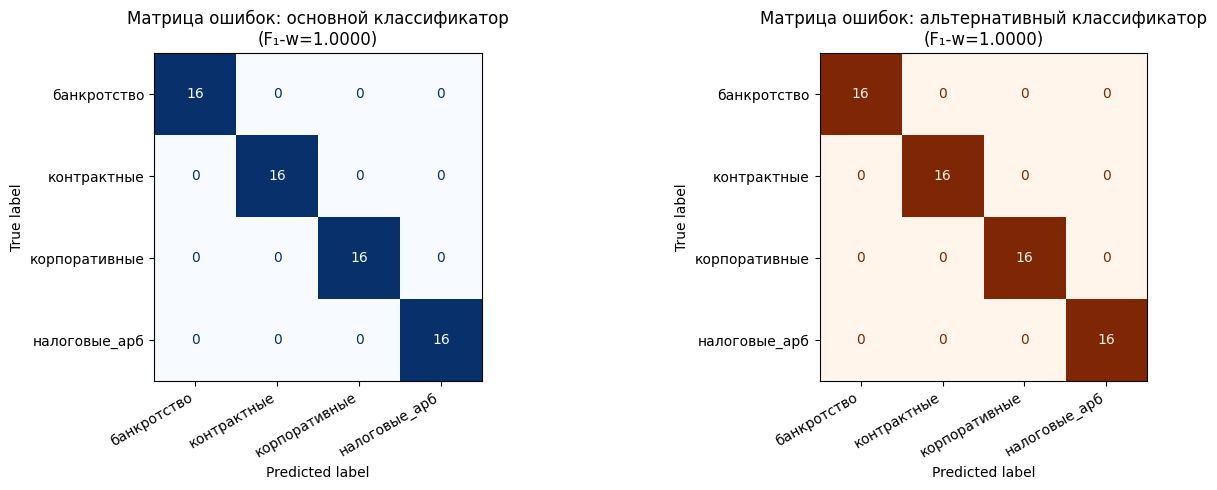


=== Сравнение классификаторов ===
     Классификатор  Accuracy  F₁-macro  F₁-weighted
LogisticRegression       1.0       1.0          1.0
         LinearSVC       1.0       1.0          1.0


In [17]:
# ── Матрица ошибок ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_sorted = sorted(set(y))

cm_main = confusion_matrix(y_test, y_pred_main, labels=labels_sorted)
disp = ConfusionMatrixDisplay(cm_main, display_labels=labels_sorted)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title(f'Матрица ошибок: основной классификатор\n'
                  f'(F₁-w={f1w_main:.4f})')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# ── Альтернативный классификатор (выбор студента) ──────────
# Замените alt_clf на другой классификатор по своему выбору
alt_clf = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
alt_clf.fit(X_train, y_train)
y_pred_alt = alt_clf.predict(X_test)

acc_alt  = accuracy_score(y_test, y_pred_alt)
f1m_alt  = f1_score(y_test, y_pred_alt, average='macro')
f1w_alt  = f1_score(y_test, y_pred_alt, average='weighted')

cm_alt = confusion_matrix(y_test, y_pred_alt, labels=labels_sorted)
disp2 = ConfusionMatrixDisplay(cm_alt, display_labels=labels_sorted)
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges', values_format='d')
axes[1].set_title(f'Матрица ошибок: альтернативный классификатор\n'
                  f'(F₁-w={f1w_alt:.4f})')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('task3_classifiers.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Итоговое сравнение ─────────────────────────────────────
comparison = pd.DataFrame({
    'Классификатор': [type(main_clf).__name__,
                      type(alt_clf).__name__],
    'Accuracy':    [acc_main, acc_alt],
    'F₁-macro':   [f1m_main, f1m_alt],
    'F₁-weighted': [f1w_main, f1w_alt],
})
print("\n=== Сравнение классификаторов ===")
print(comparison.to_string(index=False))

### Задание 4. Специализированный анализ (определяется вариантом)

#### 4.6. Нейросетевая классификация (MLP / sklearn) (варианты 6, 11, 16, 21, 26, 33)

SVD: (320, 204) → (320, 50)  (объяснено 0.9820 дисперсии)
t-SNE завершён. KL-дивергенция: 0.8773


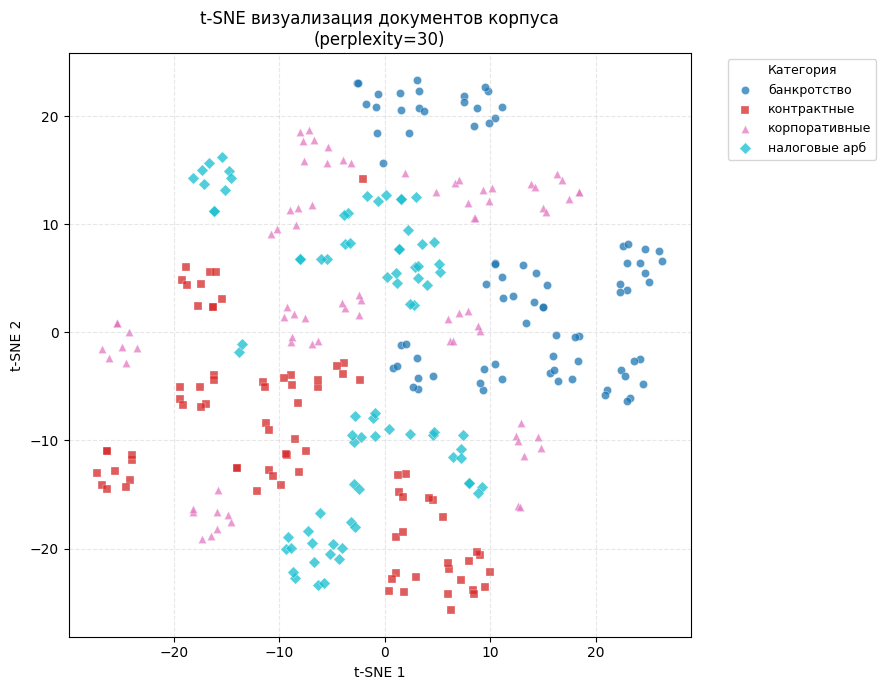

In [18]:
# ============================================================
# Задание 4.4: Визуализация методом t-SNE
# Варианты: 4, 9, 14, 19, 30, 32
# ============================================================

from sklearn.manifold import TSNE

# ── Снижение размерности: TF-IDF → SVD → t-SNE ─────────────
X_all_vec = vectorizer.transform(X_raw)
svd50 = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
X_svd50 = svd50.fit_transform(X_all_vec)
print(f"SVD: {X_all_vec.shape} → {X_svd50.shape}  "
      f"(объяснено {svd50.explained_variance_ratio_.sum():.4f} дисперсии)")

# ── t-SNE: выберите perplexity в диапазоне [10, 50] ─────────
PERPLEXITY = 30   # TODO: подберите оптимальное значение

tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    n_iter=1000,
    random_state=RANDOM_STATE,
    learning_rate='auto',
    init='pca',
)
X_2d = tsne.fit_transform(X_svd50)
print(f"t-SNE завершён. KL-дивергенция: {tsne.kl_divergence_:.4f}")

# ── Визуализация ─────────────────────────────────────────────
unique_labels = sorted(df['label'].unique())
palette = plt.cm.get_cmap('tab10', len(unique_labels))
color_map = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
marker_map = {lbl: m for lbl, m in
              zip(unique_labels, ['o','s','^','D','P','*','X','h'])}

fig, ax = plt.subplots(figsize=(9, 7))
for label_ in unique_labels:
    idx = [i for i, l in enumerate(df['label'].tolist()) if l == label_]
    ax.scatter(
        X_2d[idx, 0], X_2d[idx, 1],
        c=[color_map[label_]], marker=marker_map[label_],
        s=35, alpha=0.75, edgecolors='white', linewidths=0.3,
        label=label_.replace('_', ' ')
    )
ax.set(
    title=f't-SNE визуализация документов корпуса\n'
          f'(perplexity={PERPLEXITY})',
    xlabel='t-SNE 1', ylabel='t-SNE 2',
)
ax.legend(title='Категория', fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('task4_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

# TODO: проанализируйте полученную диаграмму.
# Чётко ли разделены кластеры? Есть ли пересечения?
# Что говорит это о сложности задачи классификации?


## Приложение. Шаблон настройки варианта


In [15]:
# ============================================================
# КОНФИГУРАЦИЯ ВАРИАНТА
# Заполните переменные согласно своему варианту
# ============================================================

# ─── Номер варианта ─────────────────────────────────────────
VARIANT_NUMBER = 19   # <-- введите номер своего варианта (1–30)

# ─── Таблица конфигураций ────────────────────────────────────
VARIANT_CONFIG = {
    #  (тип, ngram_min, ngram_max, analyzer, max_feat, classifier, extra_task)
    1:  ('A','word',1,1,'CountVectorizer',2000,'LogisticRegression','anomaly'),
    2:  ('A','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','lda'),
    3:  ('A','word',2,2,'TfidfVectorizer',3000,'RandomForest','search'),
    4:  ('A','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','tsne'),
    5:  ('A','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','gridsearch'),
    6:  ('A','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','mlp'),

    7:  ('B','word',1,1,'CountVectorizer',2000,'LogisticRegression','lda'),
    8:  ('B','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','search'),
    9:  ('B','word',2,2,'TfidfVectorizer',3000,'RandomForest','tsne'),
    10: ('B','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','gridsearch'),
    11: ('B','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','mlp'),
    12: ('B','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','anomaly'),

    13: ('C','word',1,1,'CountVectorizer',2000,'LogisticRegression','search'),
    14: ('C','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','tsne'),
    15: ('C','word',2,2,'TfidfVectorizer',3000,'RandomForest','gridsearch'),
    16: ('C','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','mlp'),
    17: ('C','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','anomaly'),
    18: ('C','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','lda'),

    19: ('D','word',1,1,'CountVectorizer',2000,'LogisticRegression','tsne'),
    20: ('D','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','gridsearch'),
    21: ('D','word',2,2,'TfidfVectorizer',3000,'RandomForest','mlp'),
    22: ('D','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','anomaly'),
    23: ('D','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','lda'),
    24: ('D','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','search'),

    25: ('E','word',1,1,'CountVectorizer',2000,'LogisticRegression','gridsearch'),
    26: ('E','word',1,1,'TfidfVectorizer',3000,'MultinomialNB','mlp'),
    27: ('E','word',2,2,'TfidfVectorizer',3000,'RandomForest','anomaly'),
    28: ('E','char_wb',3,5,'CountVectorizer',5000,'LinearSVC','lda'),
    29: ('E','word',3,3,'TfidfVectorizer',3000,'GradientBoosting','search'),
    30: ('E','word',1,2,'TfidfVectorizer',5000,'MLPClassifier','tsne'),
}

vcfg = VARIANT_CONFIG[VARIANT_NUMBER]
print(f"=== Конфигурация варианта {VARIANT_NUMBER} ===")
print(f"Тип корпуса:               {vcfg[0]} — {CORPUS_CONFIG[vcfg[0]]['label']}")
print(f"Описание:                  {CORPUS_CONFIG[vcfg[0]]['description']}")
print(f"Анализатор:                {vcfg[1]}")
print(f"Диапазон n-грамм:          ({vcfg[2]}, {vcfg[3]})")
print(f"Векторизатор:              {vcfg[4]}, max_features={vcfg[5]}")
print(f"Основной классификатор:    {vcfg[6]}")
print(f"Дополнительное задание:    {vcfg[7]}")

CORPUS_TYPE    = vcfg[0]
EXTRA_TASK     = vcfg[7]

print(f"\nВыполняйте задания в ячейках ниже,")
print(f"используя параметры своего варианта.")
print(f"Дополнительное задание 4: блок '{EXTRA_TASK}'")


=== Конфигурация варианта 19 ===
Тип корпуса:               D — Арбитражные споры
Описание:                  корпоративные, банкротные, налоговые и контрактные споры
Анализатор:                word
Диапазон n-грамм:          (1, 1)
Векторизатор:              CountVectorizer, max_features=2000
Основной классификатор:    LogisticRegression
Дополнительное задание:    tsne

Выполняйте задания в ячейках ниже,
используя параметры своего варианта.
Дополнительное задание 4: блок 'tsne'
